In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
df=pd.read_csv('energy_dataset.csv')

In [5]:
df.head()

,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2015-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,...,196.0,0.0,6378.0,17,NaN,6436,26118,25385.0,50.10,65.41
1,2015-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,...,195.0,0.0,5890.0,16,NaN,5856,24934,24382.0,48.10,64.92
2,2015-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,...,196.0,0.0,5461.0,8,NaN,5454,23515,22734.0,47.33,64.48
3,2015-01-01 03:00:00+01:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,...,191.0,0.0,5238.0,2,NaN,5151,22642,21286.0,42.27,59.32
4,2015-01-01 04:00:00+01:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,...,189.0,0.0,4935.0,9,NaN,4861,21785,20264.0,38.41,56.04


In [6]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.isnull().sum()

generation biomass                             19
generation fossil brown coal/lignite           18
generation fossil gas                          18
generation fossil hard coal                    18
generation fossil oil                          19
generation hydro pumped storage consumption    19
generation hydro run-of-river and poundage     19
generation hydro water reservoir               18
generation nuclear                             17
generation other                               18
generation other renewable                     18
generation solar                               18
generation waste                               19
generation wind onshore                        18
forecast solar day ahead                        0
forecast wind onshore day ahead                 0
total load forecast                             0
total load actual                              36
price day ahead                                 0
price actual                                    0


In [8]:
df = df.drop(['time'], axis = 1)

In [9]:
df.nunique()

generation biomass                               423
generation fossil brown coal/lignite             956
generation fossil coal-derived gas                 1
generation fossil gas                           8297
generation fossil hard coal                     7266
generation fossil oil                            321
generation fossil oil shale                        1
generation fossil peat                             1
generation geothermal                              1
generation hydro pumped storage aggregated         0
generation hydro pumped storage consumption     3311
generation hydro run-of-river and poundage      1684
generation hydro water reservoir                7029
generation marine                                  1
generation nuclear                              2388
generation other                                 103
generation other renewable                        78
generation solar                                5331
generation waste                              

In [13]:
df = df.drop([
    'generation hydro pumped storage aggregated',
    'forecast wind offshore eday ahead',
    'generation fossil coal-derived gas',
    'generation fossil oil shale',
    'generation fossil peat',
    'generation geothermal',
    'generation marine',
    'generation wind offshore'
], axis=1)


In [14]:
df

,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind onshore,forecast solar day ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,447.0,329.0,4844.0,4821.0,162.0,863.0,1051.0,1899.0,7096.0,43.0,73.0,49.0,196.0,6378.0,17,6436,26118,25385.0,50.10,65.41
1,449.0,328.0,5196.0,4755.0,158.0,920.0,1009.0,1658.0,7096.0,43.0,71.0,50.0,195.0,5890.0,16,5856,24934,24382.0,48.10,64.92
2,448.0,323.0,4857.0,4581.0,157.0,1164.0,973.0,1371.0,7099.0,43.0,73.0,50.0,196.0,5461.0,8,5454,23515,22734.0,47.33,64.48
3,438.0,254.0,4314.0,4131.0,160.0,1503.0,949.0,779.0,7098.0,43.0,75.0,50.0,191.0,5238.0,2,5151,22642,21286.0,42.27,59.32
4,428.0,187.0,4130.0,3840.0,156.0,1826.0,953.0,720.0,7097.0,43.0,74.0,42.0,189.0,4935.0,9,4861,21785,20264.0,38.41,56.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,297.0,0.0,7634.0,2628.0,178.0,1.0,1135.0,4836.0,6073.0,63.0,95.0,85.0,277.0,3113.0,96,3253,30619,30653.0,68.85,77.02
35060,296.0,0.0,7241.0,2566.0,174.0,1.0,1172.0,3931.0,6074.0,62.0,95.0,33.0,280.0,3288.0,51,3353,29932,29735.0,68.40,76.16
35061,292.0,0.0,7025.0,2422.0,168.0,50.0,1148.0,2831.0,6076.0,61.0,94.0,31.0,286.0,3503.0,36,3404,27903,28071.0,66.88,74.30
35062,293.0,0.0,6562.0,2293.0,163.0,108.0,1128.0,2068.0,6075.0,61.0,93.0,31.0,287.0,3586.0,29,3273,25450,25801.0,63.93,69.89


In [15]:
object_columns = df.select_dtypes(include=['object']).columns
print("Object type columns:")
print(object_columns)

numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
print("\nNumerical type columns:")
print(numerical_columns)

Object type columns:
Index([], dtype='object')

Numerical type columns:
Index(['generation biomass', 'generation fossil brown coal/lignite',
       'generation fossil gas', 'generation fossil hard coal',
       'generation fossil oil', 'generation hydro pumped storage consumption',
       'generation hydro run-of-river and poundage',
       'generation hydro water reservoir', 'generation nuclear',
       'generation other', 'generation other renewable', 'generation solar',
       'generation waste', 'generation wind onshore',
       'forecast solar day ahead', 'forecast wind onshore day ahead',
       'total load forecast', 'total load actual', 'price day ahead',
       'price actual'],
      dtype='object')


In [17]:
def classify_features(df):
    categorical_features = []
    non_categorical_features = []
    discrete_features = []
    continuous_features = []

    for column in df.columns:
        if df[column].dtype == 'object':
            if df[column].nunique() < 30:
                categorical_features.append(column)
            else:
                non_categorical_features.append(column)
        elif df[column].dtype in ['int64', 'float64']: # here 64 is the 64 bit Operating System
            if df[column].nunique() < 30:
                discrete_features.append(column)
            else:
                continuous_features.append(column)

    return categorical_features, non_categorical_features, discrete_features, continuous_features

In [18]:
categorical, non_categorical, discrete, continuous = classify_features(df)

In [19]:
print("Categorical Features:", categorical)
print("Non-Categorical Features:", non_categorical)
print("Discrete Features:", discrete)
print("Continuous Features:", continuous)

Categorical Features: []
Non-Categorical Features: []
Discrete Features: []
Continuous Features: ['generation biomass', 'generation fossil brown coal/lignite', 'generation fossil gas', 'generation fossil hard coal', 'generation fossil oil', 'generation hydro pumped storage consumption', 'generation hydro run-of-river and poundage', 'generation hydro water reservoir', 'generation nuclear', 'generation other', 'generation other renewable', 'generation solar', 'generation waste', 'generation wind onshore', 'forecast solar day ahead', 'forecast wind onshore day ahead', 'total load forecast', 'total load actual', 'price day ahead', 'price actual']


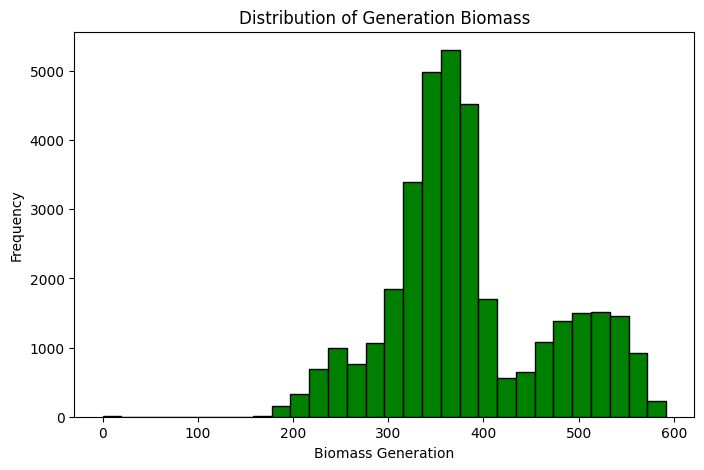

In [22]:
plt.figure(figsize=(8,5))
plt.hist(df['generation biomass'], bins=30, color='green', edgecolor='black')
plt.title("Distribution of Generation Biomass")
plt.xlabel("Biomass Generation")
plt.ylabel("Frequency")
plt.show()


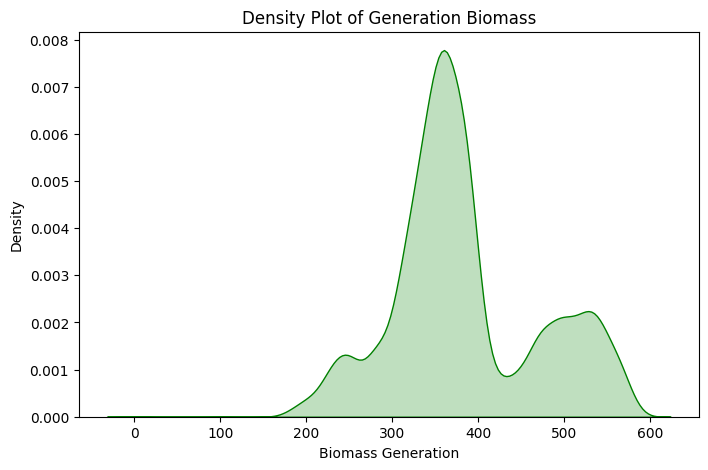

In [25]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.kdeplot(df['generation biomass'], fill=True, color='green')
plt.title("Density Plot of Generation Biomass")
plt.xlabel("Biomass Generation")
plt.ylabel("Density")
plt.show()


In [26]:
# Check skewness
skew_value = df['generation biomass'].skew()
print("Skewness of 'generation biomass':", skew_value)


Skewness of 'generation biomass': 0.42101260594207296


In [28]:
# Fill missing values in 'generation biomass' with the mean
df['generation biomass'] = df['generation biomass'].fillna(df['generation biomass'].mean())




In [29]:
df.isnull().sum()

generation biomass                              0
generation fossil brown coal/lignite           18
generation fossil gas                          18
generation fossil hard coal                    18
generation fossil oil                          19
generation hydro pumped storage consumption    19
generation hydro run-of-river and poundage     19
generation hydro water reservoir               18
generation nuclear                             17
generation other                               18
generation other renewable                     18
generation solar                               18
generation waste                               19
generation wind onshore                        18
forecast solar day ahead                        0
forecast wind onshore day ahead                 0
total load forecast                             0
total load actual                              36
price day ahead                                 0
price actual                                    0


Skewness of 'generation biomass': 0.42
Filled missing values in 'generation biomass' with mean


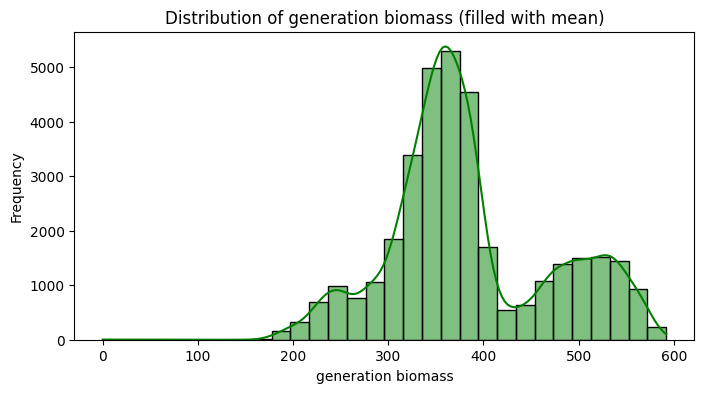

Skewness of 'generation fossil brown coal/lignite': -0.05
Filled missing values in 'generation fossil brown coal/lignite' with mean


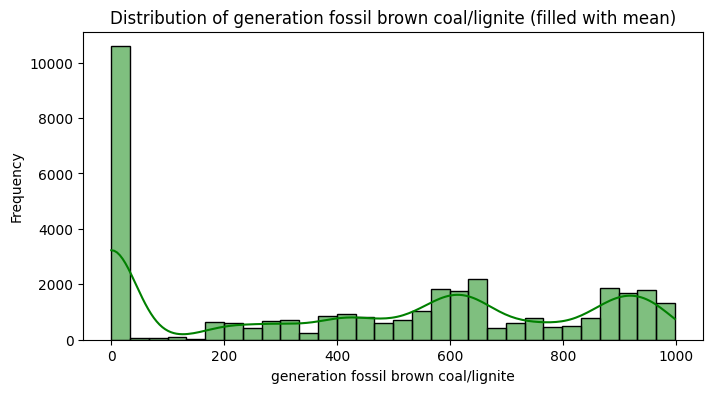

Skewness of 'generation fossil gas': 1.62
Filled missing values in 'generation fossil gas' with median


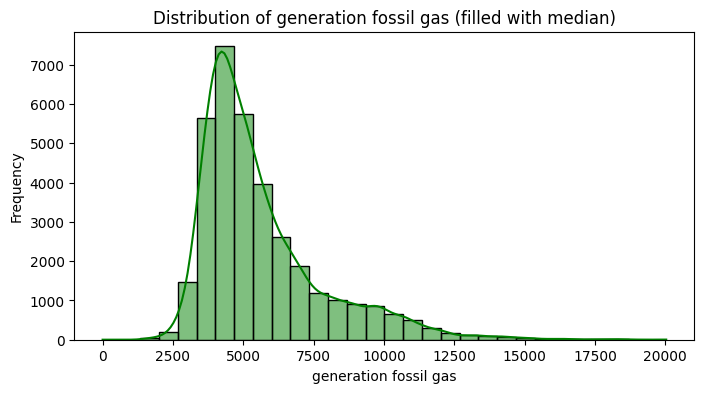

Skewness of 'generation fossil hard coal': -0.07
Filled missing values in 'generation fossil hard coal' with mean


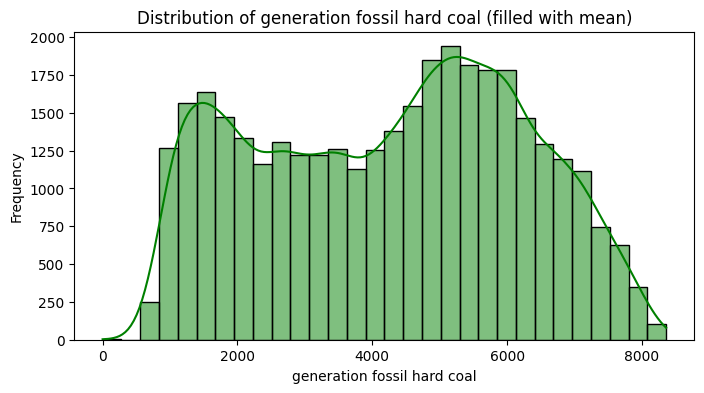

Skewness of 'generation fossil oil': 0.06
Filled missing values in 'generation fossil oil' with mean


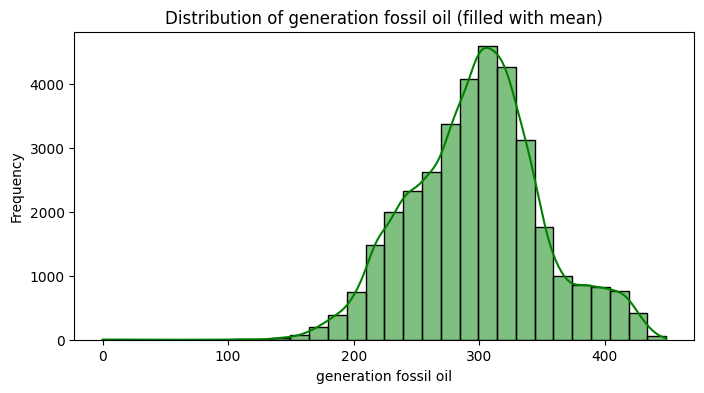

Skewness of 'generation hydro pumped storage consumption': 2.13
Filled missing values in 'generation hydro pumped storage consumption' with median


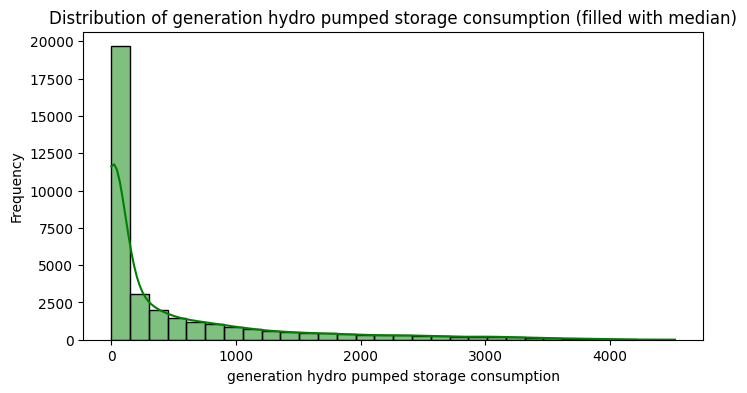

Skewness of 'generation hydro run-of-river and poundage': 0.50
Filled missing values in 'generation hydro run-of-river and poundage' with median


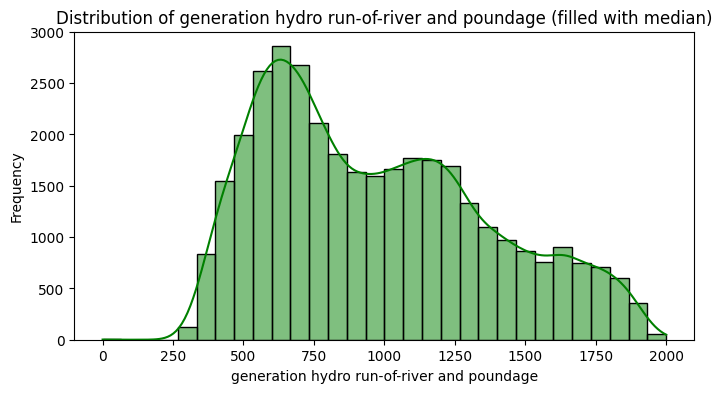

Skewness of 'generation hydro water reservoir': 0.90
Filled missing values in 'generation hydro water reservoir' with median


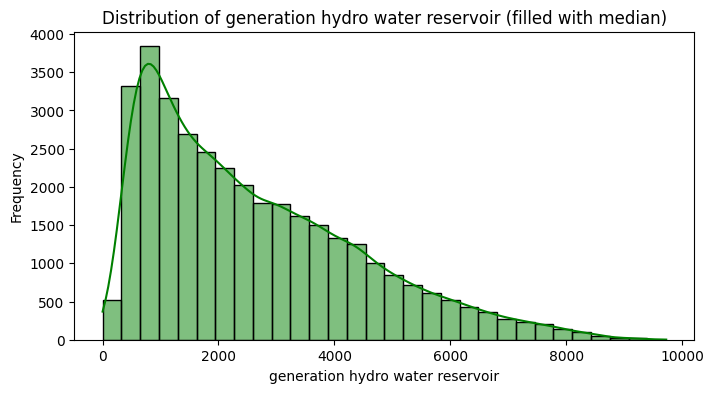

Skewness of 'generation nuclear': -0.69
Filled missing values in 'generation nuclear' with median


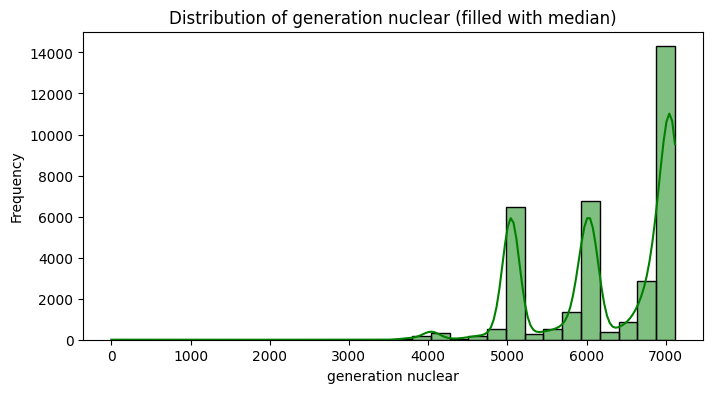

Skewness of 'generation other': -0.51
Filled missing values in 'generation other' with median


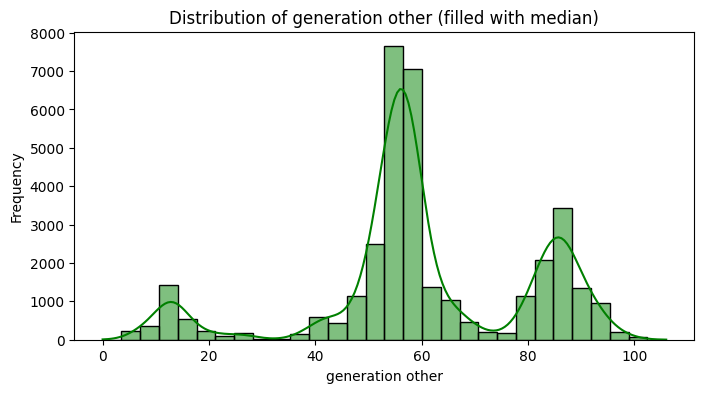

Skewness of 'generation other renewable': -0.22
Filled missing values in 'generation other renewable' with mean


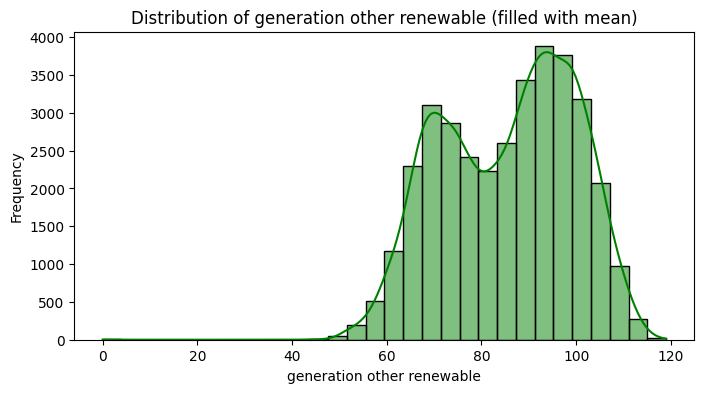

Skewness of 'generation solar': 1.02
Filled missing values in 'generation solar' with median


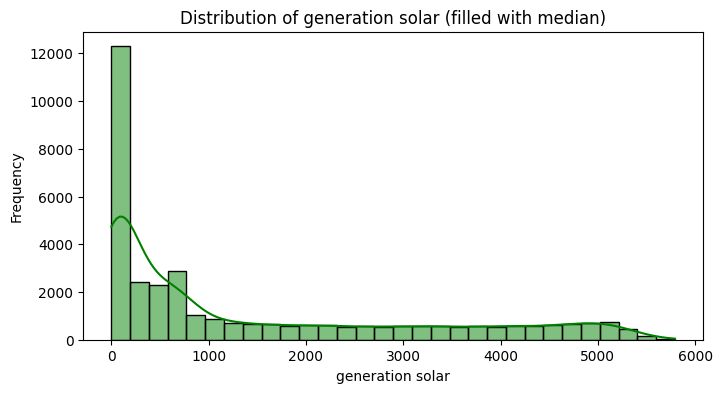

Skewness of 'generation waste': -0.85
Filled missing values in 'generation waste' with median


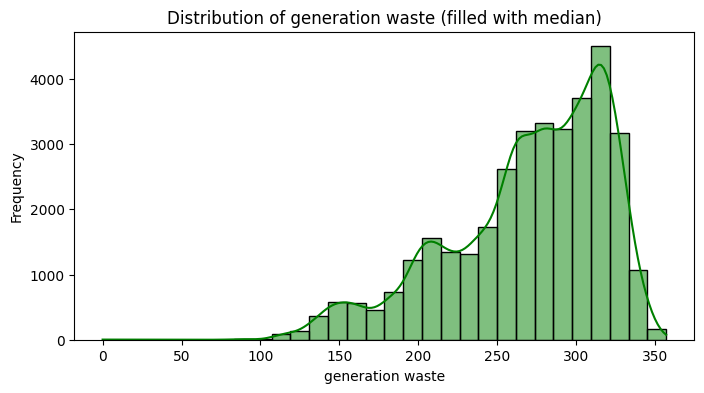

Skewness of 'generation wind onshore': 0.79
Filled missing values in 'generation wind onshore' with median


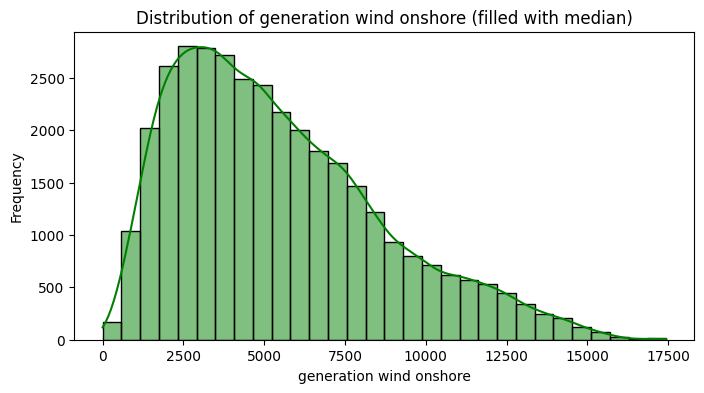

Skewness of 'forecast solar day ahead': 0.99
Filled missing values in 'forecast solar day ahead' with median


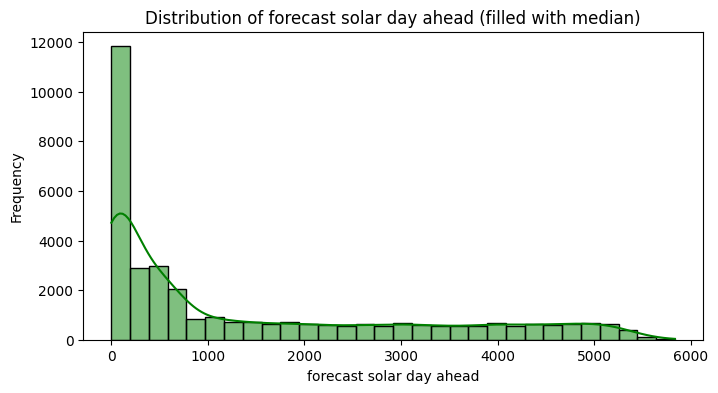

Skewness of 'forecast wind onshore day ahead': 0.80
Filled missing values in 'forecast wind onshore day ahead' with median


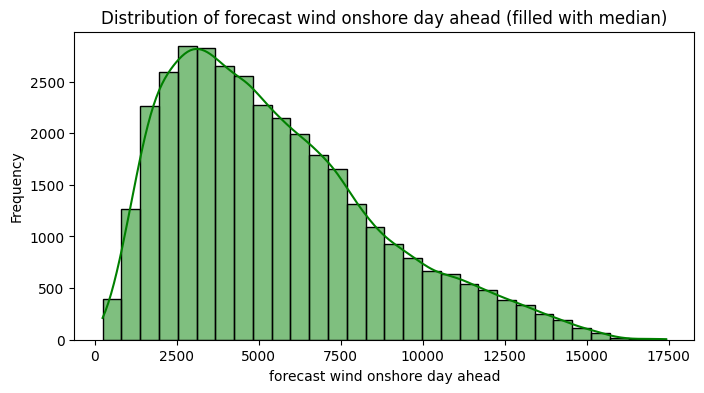

Skewness of 'total load forecast': 0.06
Filled missing values in 'total load forecast' with mean


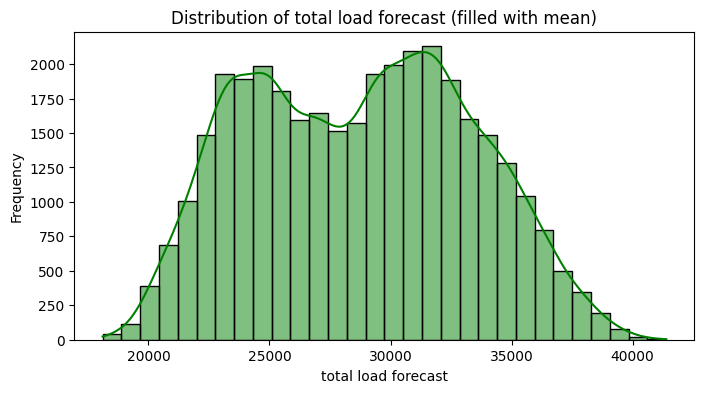

Skewness of 'total load actual': 0.06
Filled missing values in 'total load actual' with mean


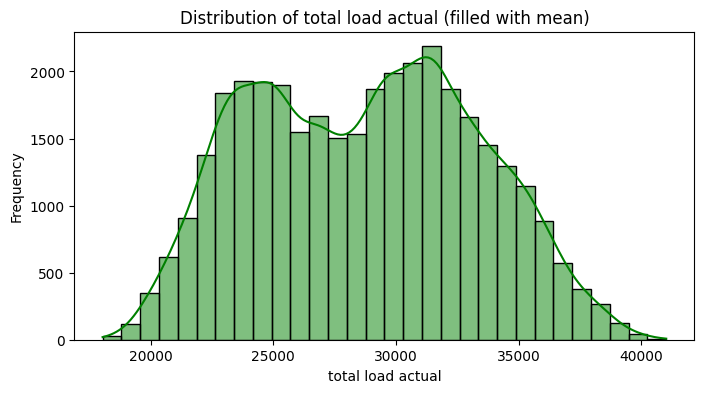

Skewness of 'price day ahead': -0.49
Filled missing values in 'price day ahead' with mean


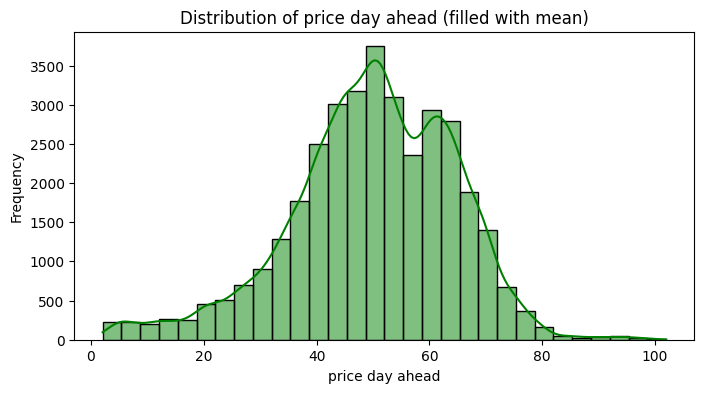

Skewness of 'price actual': -0.32
Filled missing values in 'price actual' with mean


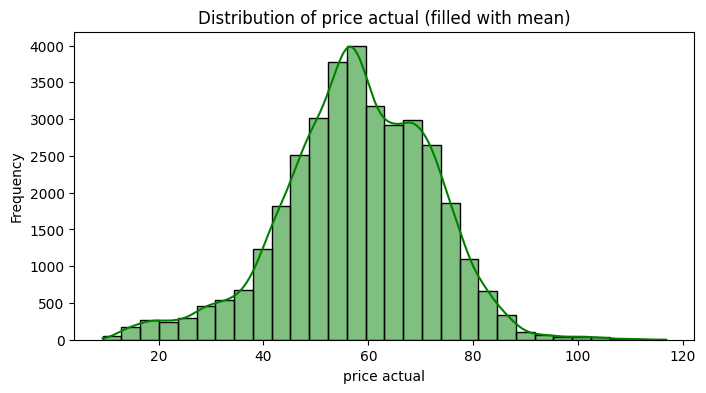

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of continuous columns (replace with your actual continuous columns)
continuous_cols = [
    'generation biomass',
    'generation fossil brown coal/lignite',
    'generation fossil gas',
    'generation fossil hard coal',
    'generation fossil oil',
    'generation hydro pumped storage consumption',
    'generation hydro run-of-river and poundage',
    'generation hydro water reservoir',
    'generation nuclear',
    'generation other',
    'generation other renewable',
    'generation solar',
    'generation waste',
    'generation wind onshore',
    'forecast solar day ahead',
    'forecast wind onshore day ahead',
    'total load forecast',
    'total load actual',
    'price day ahead',
    'price actual'
]

for col in continuous_cols:
    skew_value = df[col].skew()
    print(f"Skewness of '{col}': {skew_value:.2f}")
    
    # Fill missing values: mean if fairly symmetric, else median
    if abs(skew_value) < 0.5:
        df[col] = df[col].fillna(df[col].mean())
        fill_type = 'mean'
    else:
        df[col] = df[col].fillna(df[col].median())
        fill_type = 'median'
    
    print(f"Filled missing values in '{col}' with {fill_type}")
    
    # Plot distribution
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True, color='green', bins=30)
    plt.title(f"Distribution of {col} (filled with {fill_type})")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


In [31]:
df.isnull().sum()

generation biomass                             0
generation fossil brown coal/lignite           0
generation fossil gas                          0
generation fossil hard coal                    0
generation fossil oil                          0
generation hydro pumped storage consumption    0
generation hydro run-of-river and poundage     0
generation hydro water reservoir               0
generation nuclear                             0
generation other                               0
generation other renewable                     0
generation solar                               0
generation waste                               0
generation wind onshore                        0
forecast solar day ahead                       0
forecast wind onshore day ahead                0
total load forecast                            0
total load actual                              0
price day ahead                                0
price actual                                   0
dtype: int64

In [32]:
object_columns = df.select_dtypes(include=['object']).columns
print("Object type columns:")
print(object_columns)

numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
print("\nNumerical type columns:")
print(numerical_columns)

Object type columns:
Index([], dtype='object')

Numerical type columns:
Index(['generation biomass', 'generation fossil brown coal/lignite',
       'generation fossil gas', 'generation fossil hard coal',
       'generation fossil oil', 'generation hydro pumped storage consumption',
       'generation hydro run-of-river and poundage',
       'generation hydro water reservoir', 'generation nuclear',
       'generation other', 'generation other renewable', 'generation solar',
       'generation waste', 'generation wind onshore',
       'forecast solar day ahead', 'forecast wind onshore day ahead',
       'total load forecast', 'total load actual', 'price day ahead',
       'price actual'],
      dtype='object')


In [33]:
print("Categorical Features:", categorical)
print("Non-Categorical Features:", non_categorical)
print("Discrete Features:", discrete)
print("Continuous Features:", continuous)

Categorical Features: []
Non-Categorical Features: []
Discrete Features: []
Continuous Features: ['generation biomass', 'generation fossil brown coal/lignite', 'generation fossil gas', 'generation fossil hard coal', 'generation fossil oil', 'generation hydro pumped storage consumption', 'generation hydro run-of-river and poundage', 'generation hydro water reservoir', 'generation nuclear', 'generation other', 'generation other renewable', 'generation solar', 'generation waste', 'generation wind onshore', 'forecast solar day ahead', 'forecast wind onshore day ahead', 'total load forecast', 'total load actual', 'price day ahead', 'price actual']


In [35]:
from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()
df[continuous]=scaler.fit_transform(df[continuous])

In [58]:
X = df.drop(['price actual'], axis = 1)
y = df['price actual']

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [61]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [62]:
y_pred = lr_model.predict(X_test)

In [63]:
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

Mean Squared Error: 0.007827904478164983


In [64]:
from sklearn.metrics import mean_squared_error, r2_score

In [65]:
from sklearn import svm
svr = svm.SVR()
svr.fit(X_train, y_train)
y_pred = svr.predict(X_test)

In [66]:
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 0.006273653991419677
R2 Score: 0.643176285562242
